# Intro

In this tutorial, we reproduce genomic distance and compartment-related results of Fig5a,b in the manuscript.

# Setting directory and loading required packages

In [1]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(
  here, dplyr, data.table,ggplot2,scales,ggpubr
)


DIR <- here::here()   # resolves to the repo root automatically

# Reading in gene location information

In [2]:
gene_tbl=readRDS(paste0(DIR,'/data/auxiliary/gene_tbl.rds'))

# Reading in ARGEN fit results (ran in Tutorial 3) and combining them with gene location information.

In [3]:
chrlist=paste0('chr',c(1:22,"X"))
edges_all_chr=c()
called_edges_all_chr=c()
for(chr in c(1:23)){
    
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')

edges=do.call('rbind',dag_artifact$dag_object$edge_structure_all)
  
edges <- edges %>%
  mutate(from = sub("\\.\\d+$", "", from),
         to   = sub("\\.\\d+$", "", to))    

    
edges_annot <- edges %>%
  left_join(gene_tbl %>% dplyr::select(gene_id_clean, chr, tss),
            by = c("from" = "gene_id_clean")) %>%
  dplyr::rename(chr_from = chr, tss_from = tss) %>%
  left_join(gene_tbl %>% dplyr::select(gene_id_clean, chr, tss),
            by = c("to" = "gene_id_clean"),
            suffix = c("", "_to")) %>%
  dplyr::rename(chr_to = chr, tss_to = tss)    

    
edges_same_chr <- edges_annot %>%
  filter(!is.na(tss_from), !is.na(tss_to), chr_from == chr_to)
    
edges_all_chr=rbind(edges_all_chr,edges_same_chr)    
called_edges_all_chr=rbind(called_edges_all_chr,dag_artifact$dag_edges)
}


# Calculating genomic distances

In [4]:
df_genomic_distance <- edges_all_chr %>%
  transmute(
    dist_bp = abs(tss_to - tss_from),
    nlog10p = -log10(p_raw)
  ) %>%
  filter(is.finite(nlog10p), is.finite(dist_bp), dist_bp > 0)


# Fig.5a

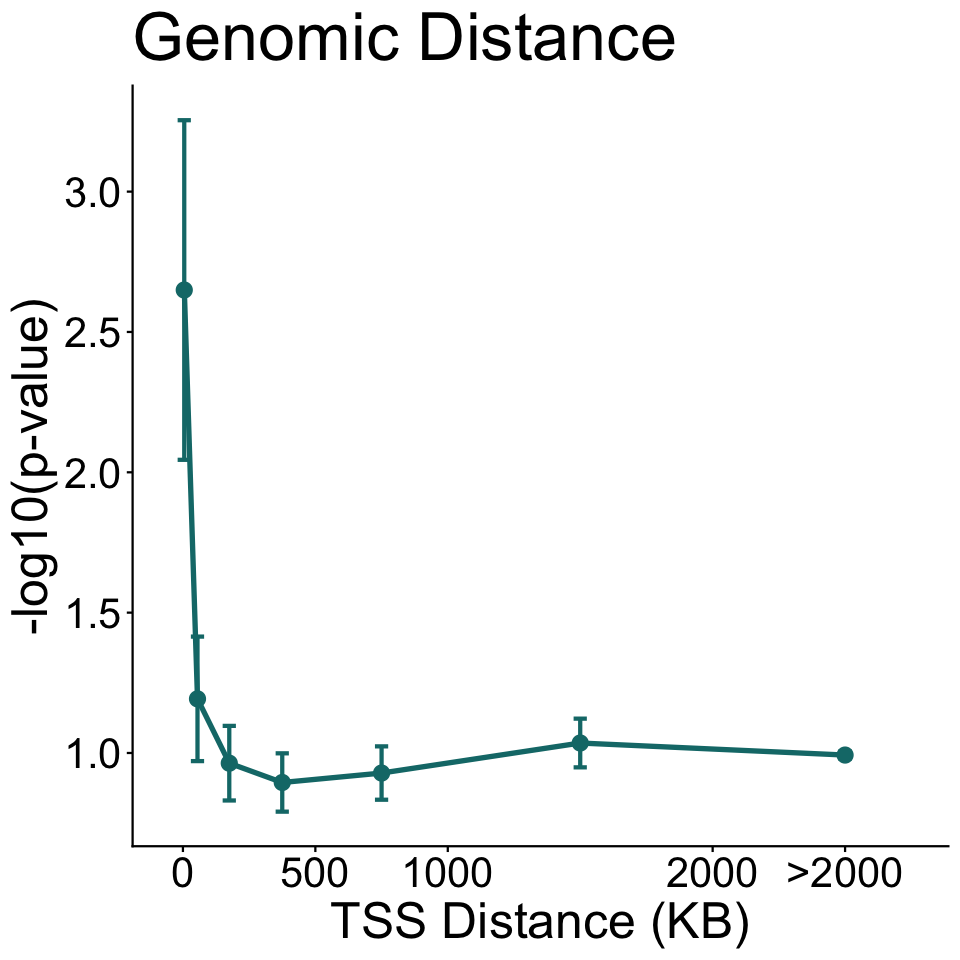

In [5]:


# 1. Define updated breaks for higher resolution at short distances
my_bin_breaks <- c(0, 10, 100, 250, 500, 1000, 2000, Inf)

df_plot <- df_genomic_distance %>%
  mutate(dist_kb = dist_bp / 1000) %>%
  mutate(bin = cut(dist_kb, breaks = my_bin_breaks, include.lowest = TRUE)) %>%
  # 2. Calculate midpoints for the x-axis
  mutate(
    bin_idx = as.numeric(bin),
    lower = my_bin_breaks[bin_idx],
    upper = my_bin_breaks[bin_idx + 1],
    # Anchor the >2000 bin at 2500
    bin_center = if_else(is.infinite(upper), 2500, (lower + upper) / 2)
  )

# 3. Plot
p <- ggplot(df_plot, aes(x = bin_center, y = nlog10p)) +
  # Error bars (Standard Error)
  stat_summary(
    fun.data = mean_se, 
    geom = "errorbar", 
    width = 50,          
    color = "#127878", 
    linewidth = 1.2
  ) +
  stat_summary(
    fun = mean, 
    geom = "line", 
    color = "#127878", 
    linewidth = 1.5,
    aes(group = 1)
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    size = 4, 
    color = "#127878"
  ) +
  labs(
    title = "Genomic Distance",
    x = "TSS Distance (KB)",
    y = "-log10(p-value)"
  ) +
  # Major axis ticks for readability
  scale_x_continuous(
    breaks = c(0, 500, 1000, 2000, 2500),
    labels = c("0", "500", "1000", "2000", ">2000"),
    limits = c(-50, 2750)
  ) +
  theme_classic(base_size = 14) +
  theme(
    axis.text   = element_text(size = 25),
    axis.title  = element_text(size = 30),
    plot.title  = element_text(size = 40)
  )
options(repr.plot.width = 8, repr.plot.height = 8)
print(p)

# Next, we show how the edge strengths differ across A and B compartments, which reproduces Fig.5 b. 

# Read in A/B compartment information of the genome.

In [6]:
compartment_dt <- readRDS(paste0(DIR,'/data/auxiliary/compartment_dt.rds'))

Load the learned DAG results across all the chromosomes.

# Reading in ARGEN fit results (ran in Tutorial 3) and combining them with compartment information.

In [7]:
chrlist <- paste0('chr', c(1:22, "X"))
edges_all_chr <- c()
called_edges_df <- c()

for(chr in c(1:23)){

DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')

  edges <- do.call('rbind', dag_artifact$dag_object$edge_structure_all)

  edges <- edges %>%
    mutate(from = sub("\\.\\d+$", "", from),
           to   = sub("\\.\\d+$", "", to))

  edges_annot <- edges %>%
    left_join(gene_tbl %>% dplyr::select(gene_id_clean, chr, tss, strand),
              by = c("from" = "gene_id_clean")) %>%
    dplyr::rename(chr_from = chr, tss_from = tss, strand_from = strand) %>%
    left_join(gene_tbl %>% dplyr::select(gene_id_clean, chr, tss, strand),
              by = c("to" = "gene_id_clean"),
              suffix = c("", "_to")) %>%
    dplyr::rename(chr_to = chr, tss_to = tss, strand_to = strand)

  edges_same_chr <- edges_annot %>% filter(chr_from == chr_to)
  edges_all_chr <- rbind(edges_all_chr, edges_same_chr)

  called_tmp <- do.call('rbind', dag_artifact$dag_object$edge_structure) %>%
    mutate(from = sub("\\.\\d+$", "", from),
           to   = sub("\\.\\d+$", "", to)) %>%
    dplyr::select(from, to)

  called_edges_df <- rbind(called_edges_df, called_tmp)
}

edges_all_chr <- as.data.table(edges_all_chr)
called_edges_df <- unique(as.data.table(called_edges_df), by = c("from","to"))

edges_all_chr[, is_called := FALSE]
edges_all_chr[called_edges_df, on = .(from, to), is_called := TRUE]





edges <- as.data.table(copy(edges_all_chr))
comp  <- as.data.table(copy(compartment_dt))

bin_size <- 1000000
up_bp    <- 1000
down_bp  <- 0

# -----------------------------
# 1) Build promoter intervals (BED-like, 0-based half-open)
#    For + strand: [TSS-10kb, TSS)
#    For - strand: [TSS, TSS+10kb)
# -----------------------------
edges[, `:=`(
  prom_from_start = ifelse(strand_from == "+", tss_from - up_bp, tss_from + down_bp),
  prom_from_end   = ifelse(strand_from == "+", tss_from + down_bp, tss_from + up_bp),

  prom_to_start   = ifelse(strand_to   == "+", tss_to   - up_bp, tss_to   + down_bp),
  prom_to_end     = ifelse(strand_to   == "+", tss_to   + down_bp, tss_to   + up_bp)
)]

# guard against negative coordinates (can happen near chr start)
edges[prom_from_start < 0, prom_from_start := 0L]
edges[prom_to_start   < 0, prom_to_start   := 0L]

# -----------------------------
# 2) Map promoter midpoint to compartment bin start
# -----------------------------
edges[, prom_from_mid := as.integer(floor((prom_from_start + prom_from_end) / 2))]
edges[, prom_to_mid   := as.integer(floor((prom_to_start   + prom_to_end)   / 2))]

edges[, bin_from := as.integer(floor(prom_from_mid / bin_size) * bin_size)]
edges[, bin_to   := as.integer(floor(prom_to_mid   / bin_size) * bin_size)]

# -----------------------------
# 3) Join compartment labels
# -----------------------------
comp_from <- unique(comp[, .(chr = chr, bin = bin, comp_from = compartment)])
comp_to   <- unique(comp[, .(chr = chr, bin = bin, comp_to   = compartment)])

setkey(comp_from, chr, bin)
setkey(comp_to,   chr, bin)

edges <- comp_from[edges, on = .(chr = chr_from, bin = bin_from)]
edges <- comp_to[edges,   on = .(chr = chr_to,   bin = bin_to)]

# -----------------------------
# 4) Build edge labels: AA/AB/BA/BB and collapsed A/B/crossAB
# -----------------------------
edges[, edge_comp_dir := fifelse(is.na(comp_from) | is.na(comp_to), NA_character_,
                                 paste0(comp_from, comp_to))]

edges[, edge_comp2 := fifelse(is.na(comp_from) | is.na(comp_to), NA_character_,
                              fifelse(comp_from == comp_to, comp_from, "crossAB"))]

edges_all_chr <- edges

# Fig.5b

For edges called significant by ARGEN, we examine the $-\log{\mbox{(p-value)}}$ of edges across the A and B compartments.

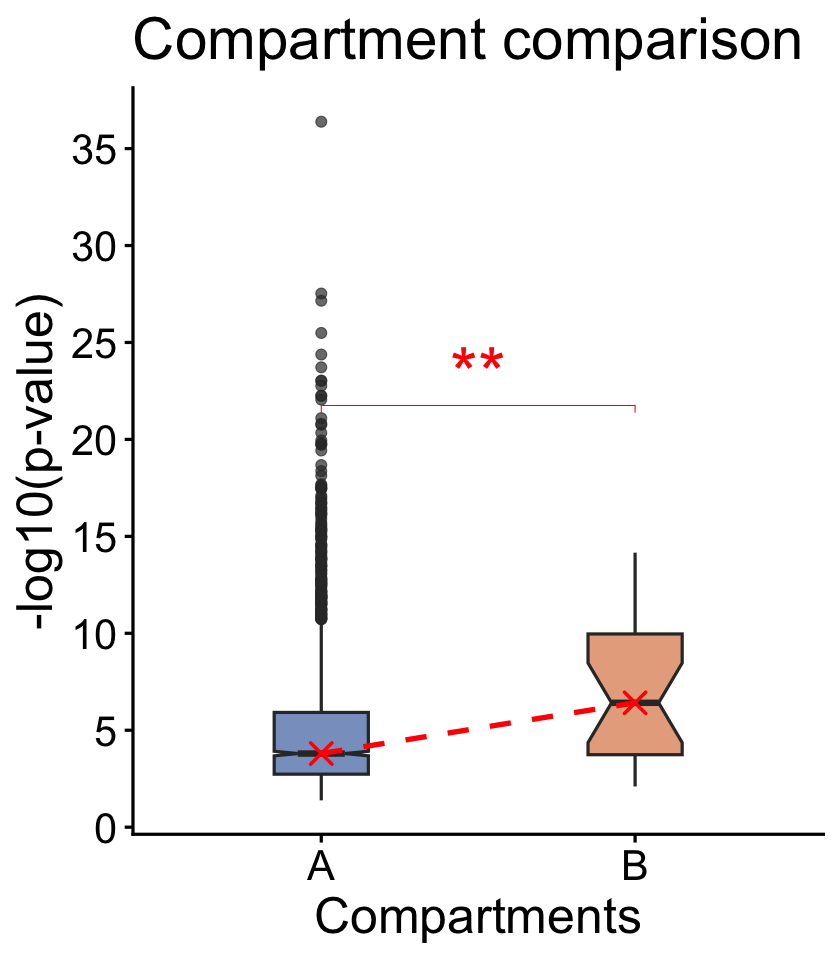

In [8]:

edges_all_chr[, nlog10p := -log10(p_raw)]
options(repr.plot.width=7, repr.plot.height=8)
plot_df <- edges_all_chr[
  edge_comp2 %in% c("A","B") &
    is.finite(nlog10p)
]

p=ggplot(plot_df %>% filter(is_called), aes(x = edge_comp2, y = nlog10p, fill = edge_comp2)) +
  geom_boxplot(notch = TRUE, width = 0.3, alpha = 0.7) +
  
  # median X marks
  stat_summary(
    fun = median,
    geom = "point",
    size = 5,
    color = "red",
    shape = 4, stroke = 1.5
  ) +
  
  # connect medians
  stat_summary(
    fun = median,
    geom = "line",
    aes(group = 1),
    linewidth = 1.5,
    lty = 2,
    color = "red"
  ) +
  stat_compare_means(
    comparisons = list(c("A", "B")),
    method = "wilcox.test",
    alternative = "greater",
    label = "p.signif",
    size = 15,
    color = "red",    label.y =20,
    tip.length = 0.01 
  )+
  
  scale_fill_manual(
    values = c(
      "A" = "#4C72B0",  
      "B" = "#DD8452"  
    )
  ) +ggtitle("Compartment comparison")+
  
  labs(x = "Compartments", y = "-log10(p-value)") +
  theme_classic(base_size = 20) +
  theme(legend.position = "none",plot.title=element_text(size=35))+ scale_y_continuous(breaks = seq(0, max(plot_df$nlog10p, na.rm = TRUE), by = 5))+
  theme(
    axis.text = element_text(size = 25),
    axis.title = element_text(size = 30)
  )


p
